In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import xgcm
import matplotlib.pyplot as plt
import xbudget

from load_example_ecco_grid import * 
from eccov4r4_budget_diagnostics import * 
from xbudget.llc90 import * 
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xarray: 2026.4.0
xgcm: 0.9.0


In [3]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0')
print(cluster.job_script())
cluster.scale(jobs=4)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/docs_env_xbudget/bin/python -m distributed.cli.dask_worker tcp://172.16.3.190:37995 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.190:37995,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
transport_ds_path = "/vortexfs1/share/ecco/ECCOV4r4_budget_terms.zarr"

ds = xr.open_mfdataset(transport_ds_path, parallel = True, engine = "zarr").fillna(0.0).isel(time = slice(0, 12))
ds = ds.rename({"XG":"geolon_c", "YG":"geolat_c", "XC":"geolon", "YC":"geolat"}).chunk({"tile":-1, "i":-1, "j":-1, "i_g":-1, "j_g":-1}) 
grid = construct_grid(ds)

In [6]:
mask = (
    (grid._ds["geolat"] < -60.0)
    & (grid._ds["Depth"].fillna(0.0) > 1000.0)
).fillna(0.0)

# # 2. Extract closed boundary contours
face_c, i_c, j_c, lons_c, lats_c = grid_boundaries_from_mask(grid, mask)
# print(f"{len(lons_c)} closed contours")

contour 0: 21979 cells, 473 boundary points


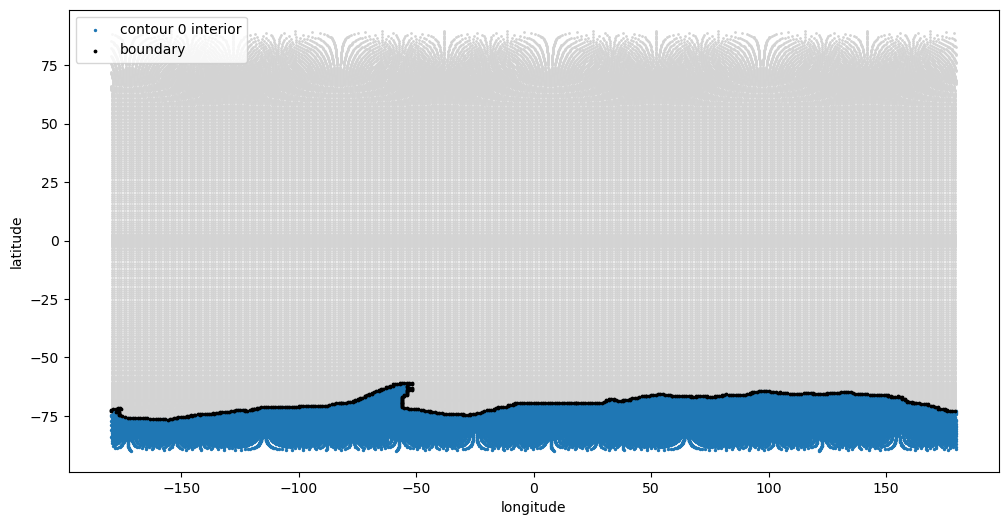

In [7]:

# 3. Pick one and rebuild its mask
k = 0
mask_k = mask_from_grid_boundaries(lons_c[k], lats_c[k], grid)
print(f"contour {k}: {int(mask_k.sum())} cells, {len(lons_c[k])} boundary points")

# 4. Plot: scatter the C-points colored by mask, overlay the boundary
lon_h = grid._ds["geolon"].values.ravel()
lat_h = grid._ds["geolat"].values.ravel()
m_flat = mask_k.values.ravel()

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(lon_h, lat_h, c="lightgray", s=1)
ax.scatter(lon_h[m_flat], lat_h[m_flat], c="C0", s=2, label=f"contour {k} interior")
ax.scatter(lons_c[k], lats_c[k], c="k", s=3, label="boundary")
# ax.plot(lons_c[k], lats_c[k], c="k", label="boundary")

ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend()
plt.show()

In [10]:
def get_trsp(ds, vel):
    if "i_g" in vel.dims:
        trsp = vel.fillna(0.0) * ds["drF"] * ds["dyG"]
        return trsp.where(ds["maskW"]).fillna(0.0)

    if "j_g" in vel.dims:
        trsp = vel.fillna(0.0) * ds["drF"] * ds["dxG"]
        return trsp.where(ds["maskS"]).fillna(0.0)

    if "k_l" in vel.dims:
        trsp = vel.fillna(0.0) * ds["rA"]
        return trsp.fillna(0.0)

    raise ValueError("Expected velocity on `i_g`, `j_g`, or `k_l`.")

In [32]:
ds = xr.open_mfdataset(transport_ds_path, parallel = True, engine = "zarr").fillna(0.0).isel(time = slice(0, 12))
grid = construct_grid(ds)

bolus_velocities = calc_uv_bolus(ds, grid, allow_rechunk=True)

# remove the "bad bolus"
ds = ds.drop_vars(["UVELSTAR", "VVELSTAR", "WVELSTAR"])
ds = xr.merge([ds, bolus_velocities])

URES_TRSP = get_trsp(ds, ds["UVELMASS"] + ds["UVELSTAR"])
VRES_TRSP = get_trsp(ds, ds["VVELMASS"] + ds["VVELSTAR"])

/vortexfs1/home/anthony.meza/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)


In [33]:
import xeos
ds["SIG2"] = xeos.rho(ds["THETA"].where(ds["hFacC"] > 0.0),
             ds["SALT"].where(ds["hFacC"] > 0.0),
             2000,
             "JMD-95")

ds["SIG2"] -= 1000

sigma2_target = np.hstack(
    [
        np.arange(0, 30, 5),
        np.arange(30, 35, 0.25),
        np.arange(35, 37, 0.025),
        np.arange(37, 37.2, 0.01),
        38,
        40,
    ])

Ures_SIG2_cons, Vres_SIG2_cons = remap_transports(
    ds,
    grid,
    URES_TRSP,
    VRES_TRSP,
    sigma2_target,
    coord_name="SIG2",
    method="conservative")

psi_cons = calc_psi_from_remapped_transports(
    ds,
    grid,
    Ures_SIG2_cons,
    Vres_SIG2_cons,
    coord_name="SIG2",
    allow_rechunk=True)

/vortexfs1/home/anthony.meza/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/vortexfs1/home/anthony.meza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 51.42 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/vortexfs1/home/anthony.meza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 51.42 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph withou

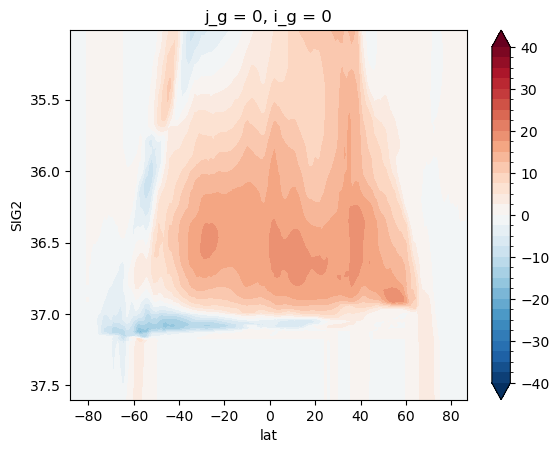

In [34]:
levels = np.arange(-40, 40 + 0.1, 2.5)
psi_cons.sel(SIG2 = slice(35, 38)).plot.contourf(x = "lat", y = "SIG2", levels = levels, extend = "both", yincrease = False)

In [35]:
ds = xr.open_mfdataset(transport_ds_path, parallel = True, engine = "zarr").fillna(0.0)
grid = construct_grid(ds)

bolus_velocities = calc_uv_bolus(ds, grid, allow_rechunk=True)

# # remove the "bad bolus"
ds = ds.drop_vars(["UVELSTAR", "VVELSTAR", "WVELSTAR"])
ds = xr.merge([ds, bolus_velocities])

/vortexfs1/home/anthony.meza/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/vortexfs1/home/anthony.meza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/xarray/structure/chunks.py:183: PerformanceWarning: Increasing number of chunks by factor of 52
  _, chunked_data = chunkmanager.unify_chunks(*unify_chunks_args)


In [36]:
URES_TRSP = get_trsp(ds, ds["UVELMASS"] + ds["UVELSTAR"])
VRES_TRSP = get_trsp(ds, ds["VVELMASS"] + ds["VVELSTAR"])

ds["SIG2"] = xeos.rho(ds["THETA"].where(ds["hFacC"] > 0.0),
             ds["SALT"].where(ds["hFacC"] > 0.0),
             2000,
             "JMD-95")

ds["SIG2"] -= 1000

sigma2_target = np.hstack(
    [
        np.arange(0, 30, 5),
        np.arange(30, 35, 0.25),
        np.arange(35, 37, 0.025),
        np.arange(37, 38, 0.015),
        38,
        40,
    ])

Ures_SIG2_cons, Vres_SIG2_cons = remap_transports(
    ds,
    grid,
    URES_TRSP,
    VRES_TRSP,
    sigma2_target,
    coord_name="SIG2",
    method="conservative")

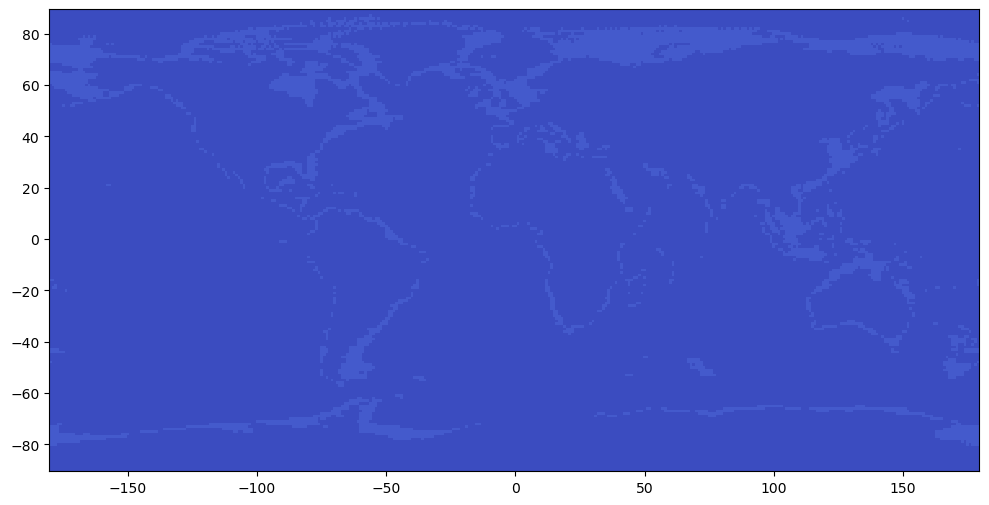

In [37]:
def plot_interpolated_ecco(fig, ax, ds, vmin=0, vmax=30, cmap="coolwarm", target_lon= None, target_lat = None, method = "nearest"):
    # Build a simple regular lat-lon target grid for quick visual comparison.
    if target_lon is None:
        target_lon = np.arange(-180, 180, 1)
    if target_lat is None: 
        target_lat = np.arange(-90, 90, 1)
    lon_grid, lat_grid = np.meshgrid(target_lon, target_lat)
    
    # Flatten the LLC field into point/value pairs for interpolation.
    points = np.column_stack((ds.XC.values.ravel(), ds.YC.values.ravel()))
    values = ds.values.ravel()
    
    # Use nearest-neighbor remapping to preserve the native diagnostic values.
    interpolated_data = griddata(points, values, (lon_grid, lat_grid), method=method)
    
    # Plot the remapped field.
    cb = ax.pcolormesh(lon_grid, lat_grid, interpolated_data, 
                       vmin=vmin, vmax=vmax, cmap=cmap)
    
    return cb
ds["mask"] = mask_k.where(mask_k > 0.0)
fig, ax = plt.subplots(figsize=(12, 6))
# plot_interpolated_ecco(fig, ax, ds["mask"])
plot_interpolated_ecco(fig, ax, (ds["Depth"] < 1000) * (ds["Depth"] > 0.0))

In [38]:
diff_UV_RES = diff_2d_flux_llc90(
    grid,
    Ures_SIG2_cons.fillna(0.0),
    Vres_SIG2_cons.fillna(0.0),
    allow_rechunk=True,
)

UVRES_CONV = -(diff_UV_RES["X"].fillna(0.0) + diff_UV_RES["Y"].fillna(0.0))
ds["mask"] = mask_k.where(mask_k > 0.0)
UVRES_CONV = UVRES_CONV.where(1 * ds["mask"] > 0.0)

/vortexfs1/home/anthony.meza/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/vortexfs1/home/anthony.meza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/xarray/structure/chunks.py:183: PerformanceWarning: Increasing number of chunks by factor of 52
  _, chunked_data = chunkmanager.unify_chunks(*unify_chunks_args)


/vortexfs1/home/anthony.meza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 76.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


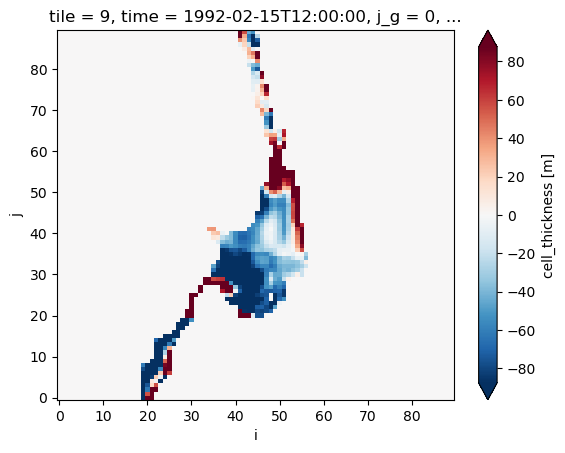

In [40]:
UVRES_CONV.isel(time = 0, tile = 9).sum("SIG2").plot(robust = True)

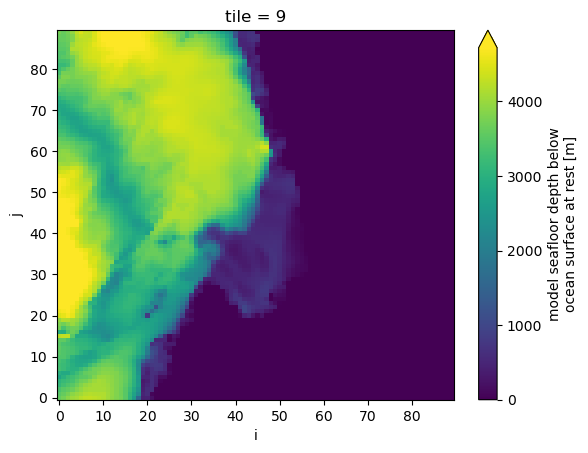

In [41]:
ds["Depth"].isel(tile = 9).plot(robust = True)

In [42]:
def reverse_cumsum(da, dim):
    return da.isel({dim: slice(None, None, -1)}).cumsum(dim).isel({dim: slice(None, None, -1)})

In [43]:
psi = reverse_cumsum(UVRES_CONV.sum(["tile", "j", "i"]), "SIG2")
psi = psi.compute()

/vortexfs1/home/anthony.meza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 76.81 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


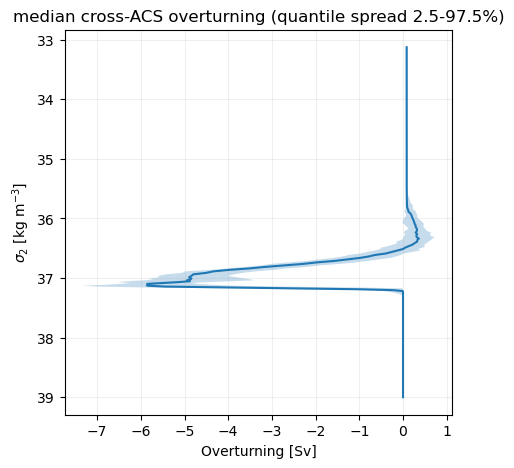

In [98]:
fig, ax = plt.subplots(figsize=(5, 5))

psi_sel = 1e-6 * psi.sel(SIG2=slice(33, 39))
psi_sel = psi_sel.groupby("time.year").mean("time")

q_lo = psi_sel.quantile(0.025, dim="year")
q_med = psi_sel.quantile(0.5, dim="year")
q_hi = psi_sel.quantile(0.975, dim="year")

line = q_med.plot(y="SIG2", ax=ax)[0]

patch = ax.fill_betweenx(
    q_med["SIG2"],
    q_lo,
    q_hi,
    alpha=0.25,
)

ax.set_title("median cross-ACS overturning (quantile spread 2.5-97.5%)")
ax.invert_yaxis()
ax.set_xlabel("Overturning [Sv]")
ax.set_ylabel(r"$\sigma_2$ [kg m$^{-3}$]")
ax.grid(alpha=0.2)

Text(0.5, 1.0, 'ECCO V4r4 ACS overturning')

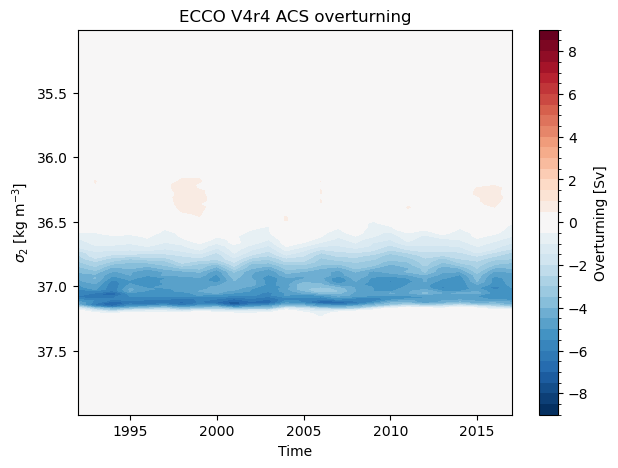

In [112]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(7, 5))

psi_sel = (1e-6 * psi).sel(SIG2=slice(35, 38))
psi_sel = psi_sel.groupby("time.year").mean("time")
levels = np.arange(-9, 9 + 0.5, 0.5)

base_cmap = plt.get_cmap("RdBu_r")
n_bins = len(levels) - 1
colors = base_cmap(np.linspace(0, 1, n_bins))

mid = n_bins // 2
center_color = base_cmap(0.5)
colors[mid - 1:mid + 1] = center_color

cmap = mpl.colors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(levels, cmap.N)

psi_sel.plot.contourf(
    x="year",
    y="SIG2",
    ax=ax,
    levels=levels,
    cmap=cmap,
    norm=norm,
    cbar_kwargs={"label": "Overturning [Sv]"},
)

ax.invert_yaxis()
ax.set_xlabel("Time")
ax.set_ylabel(r"$\sigma_2$ [kg m$^{-3}$]")
ax.set_title("ECCO V4r4 ACS overturning")

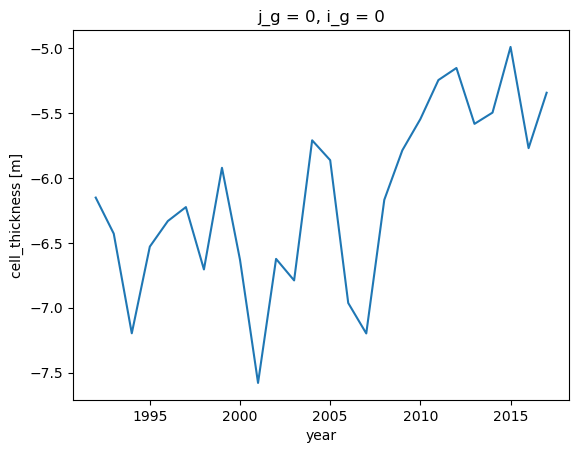

In [107]:
psi_sel.isel(SIG2 = psi_sel.argmin("SIG2")).plot()

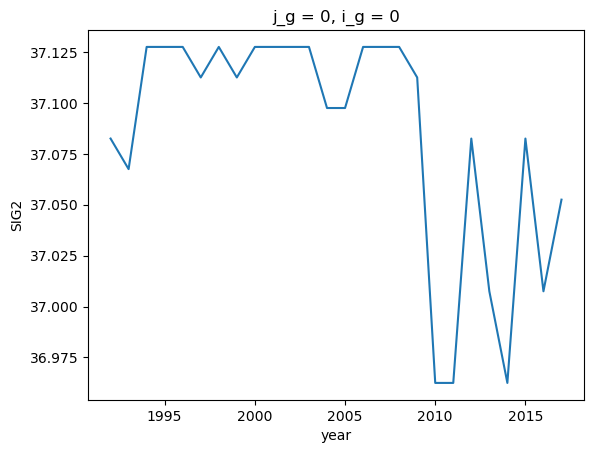

In [111]:
psi_sel.SIG2.broadcast_like(psi_sel).isel(SIG2 = psi_sel.argmin("SIG2")).plot()

In [63]:
mean_theta = ds["THETA"].mean("time").compute()
mean_salinity = ds["SALT"].mean("time").compute()

In [70]:
mean_bot_theta = mean_theta.where(mean_theta["hFacC"] > 0.0).ffill("k").isel(k = -1)
mean_bot_sal = mean_salinity.where(mean_theta["hFacC"] > 0.0).ffill("k").isel(k = -1)

mean_bot_sig = xeos.rho(mean_bot_theta,mean_bot_sal,
             2000,
             "JMD-95")

mean_bot_sig -= 1000


In [71]:
import cmocean.cm as cmo

Text(0.5, 1.0, 'ECCO V4r4 time mean bottom temperature')

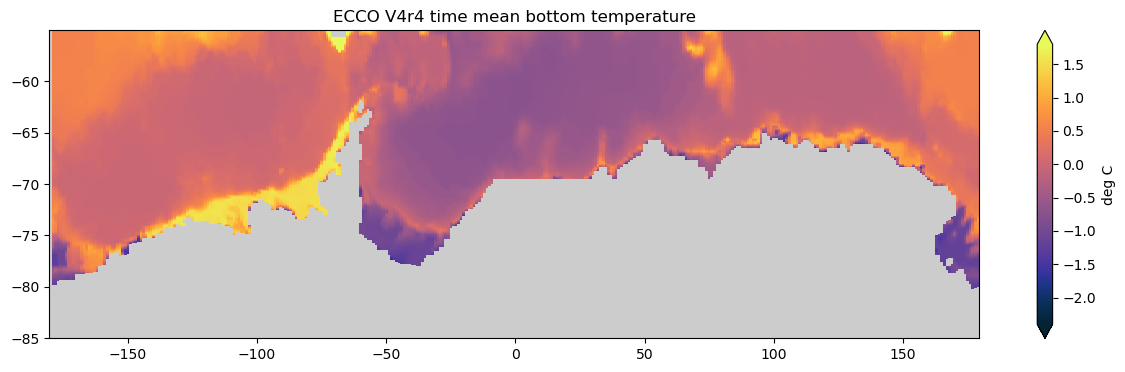

In [92]:
fig, ax = plt.subplots(figsize=(15, 4))
# plot_interpolated_ecco(fig, ax, ds["mask"])
target_lat = np.arange(-85, -55, 0.05)
target_lon = np.arange(-180, 180, 0.05)
cb = plot_interpolated_ecco(fig, ax, mean_bot_theta, 
                       vmin=-2.4, vmax=1.8, cmap=cmo.thermal, target_lon= None, target_lat = target_lat, method = "linear")
fig.colorbar(cb, extend = "both", label = "deg C")

ax.set_facecolor('0.8') # 0.0 is black, 1.0 is white, 0.8 is light gray
ax.set_title(r"ECCO V4r4 time mean bottom temperature")

Text(0.5, 1.0, 'ECCO V4r4 time mean bottom $\\sigma_2$')

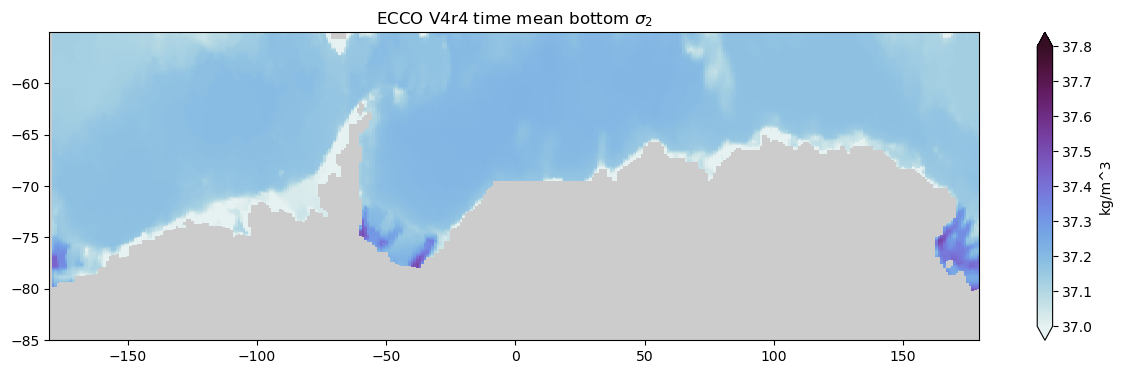

In [91]:
fig, ax = plt.subplots(figsize=(15, 4))

cb = plot_interpolated_ecco(fig, ax, mean_bot_sig, 
                       vmin=37.0, vmax=37.8, cmap=cmo.dense, target_lon= None, target_lat = target_lat, method = "linear")
fig.colorbar(cb, extend = "both", label = "kg/m^3")
ax.set_facecolor('0.8') # 0.0 is black, 1.0 is white, 0.8 is light gray
ax.set_title(r"ECCO V4r4 time mean bottom $\sigma_2$")

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))

cb = plot_interpolated_ecco(fig, ax, mean_bot_sal, 
                       vmin=34., vmax=35., cmap=cmo.haline, target_lon= None, target_lat = target_lat, method = "linear")
fig.colorbar(cb, extend = "both", label  = "PSU")
ax.set_facecolor('0.8') # 0.0 is black, 1.0 is white, 0.8 is light gray
